📗 Cellule 1 – Import des bibliothèques

In [1]:
import subprocess
import sys
import json

required_packages = [
    "tensorflow==2.12.0",
    "scikit-learn==1.3.2",
    "joblib==1.3.2",
    "matplotlib==3.7.1",
    "pandas==1.5.3",
    "numpy==1.23.5",
    "seaborn==0.13.2",
    "psycopg2-binary==2.9.10",
    "python-dotenv==1.0.0",
    "Flask==2.2.3"
]

for package in required_packages:
    print(f"\n📦 Installation de : {package}")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ {package} installé avec succès.")
    except subprocess.CalledProcessError:
        print(f"❌ Échec de l'installation pour : {package}")



📦 Installation de : tensorflow==2.12.0
✅ tensorflow==2.12.0 installé avec succès.

📦 Installation de : scikit-learn==1.3.2
✅ scikit-learn==1.3.2 installé avec succès.

📦 Installation de : joblib==1.3.2
✅ joblib==1.3.2 installé avec succès.

📦 Installation de : matplotlib==3.7.1
✅ matplotlib==3.7.1 installé avec succès.

📦 Installation de : pandas==1.5.3
✅ pandas==1.5.3 installé avec succès.

📦 Installation de : numpy==1.23.5
✅ numpy==1.23.5 installé avec succès.

📦 Installation de : seaborn==0.13.2
✅ seaborn==0.13.2 installé avec succès.

📦 Installation de : psycopg2-binary==2.9.10
✅ psycopg2-binary==2.9.10 installé avec succès.

📦 Installation de : python-dotenv==1.0.0
✅ python-dotenv==1.0.0 installé avec succès.

📦 Installation de : Flask==2.2.3
✅ Flask==2.2.3 installé avec succès.


In [2]:
import tensorflow as tf 
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout

# 📦 Importations
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

# 🤖 Machine Learning
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc
)
from sklearn.neural_network import MLPClassifier

# Jupyter display
import warnings
warnings.filterwarnings("ignore")

# Affichage
sns.set(style="whitegrid")

📗 Cellule 2 – Connexion à PostgreSQL et chargement des données

In [3]:
load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_PORT = os.getenv("DB_PORT")

def get_db_connection():
    try:
        conn = psycopg2.connect(
            dbname=DB_NAME,
            user=DB_USER,
            password=DB_PASSWORD,
            host=DB_HOST,
            port=DB_PORT
        )
        return conn
    except Exception as e:
        print(f"❌ Erreur de connexion : {e}")
        return None

def fetch_data():
    try:
        conn = get_db_connection()
        df = pd.read_sql("SELECT * FROM dataset", conn)
        conn.close()
        return df.sample(frac=1, random_state=42)
    except Exception as e:
        print(f"❌ Erreur lors du chargement : {e}")
        return None

df = fetch_data()

📗 Cellule 3 – Prétraitement

In [4]:
# Enregistrer les noms de maladies originaux
df["diseases_original"] = df["diseases"]

# Augmentation si besoin
MIN_SAMPLES_PER_CLASS = 20
class_counts = df["diseases_original"].value_counts()
classes_to_augment = class_counts[class_counts < MIN_SAMPLES_PER_CLASS]

augmented_rows = []

for label, count in classes_to_augment.items():
    class_df = df[df["diseases_original"] == label]
    if not class_df.empty:
        needed = MIN_SAMPLES_PER_CLASS - count
        duplicated = resample(class_df, replace=True, n_samples=needed, random_state=42)
        for col in class_df.columns:
            if col != "diseases_original" and df[col].dtype in [np.float64, np.int64]:
                duplicated[col] += np.random.normal(0, 0.05, size=duplicated.shape[0])
        augmented_rows.append(duplicated)

if augmented_rows:
    df = pd.concat([df] + augmented_rows, ignore_index=True)

# Nettoyage
df.fillna(0, inplace=True)

# Séparer X et y AVANT le factorize
y = df["diseases_original"]
X = df.drop(columns=["diseases", "diseases_original"])

# Encoder les features uniquement
X = X.apply(lambda col: pd.factorize(col)[0] if col.dtypes == 'object' else col)

# Encode y avec les noms
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Normalisation & PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)

# Autoencoder
input_dim = X_pca.shape[1]
encoding_dim = 32

input_layer = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_layer)
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(encoding_dim, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X_pca, X_pca, epochs=50, batch_size=64, shuffle=True, verbose=0)

encoder = Model(inputs=input_layer, outputs=encoded)
X_encoded = encoder.predict(X_pca)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, train_size=0.8, random_state=42)
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


7778/7778 [==============================] - 5s 578us/step


📗 Cellule 4 – Entraînement des modèles

In [5]:
param_grid = {
    'hidden_layer_sizes': [(512, 256, 128), (1024, 512)],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [0.001, 0.0005]
}

mlp_base = MLPClassifier(
    activation='relu',
    solver='adam',
    learning_rate='adaptive',
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42,
    verbose=False
)

random_search = RandomizedSearchCV(
    mlp_base,
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    verbose=2,
    n_jobs=-1,
    scoring='f1_macro'
)

random_search.fit(X_train, y_train)
mlp_model = random_search.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


📗 Cellule 5 – Fonction d’évaluation

In [6]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    f1 = f1_score(y_test, preds, average='macro') * 100
    acc = accuracy_score(y_test, preds) * 100
    print(f"\n📊 {name}")
    print(f"F1-score : {f1:.2f}%")
    print(f"Accuracy : {acc:.2f}%")
    print("Rapport :\n", classification_report(y_test, preds))
    return model, preds

mlp_model, preds = evaluate_model("MLP amélioré", mlp_model, X_test, y_test)


📊 MLP amélioré
F1-score : 83.28%
Accuracy : 84.45%
Rapport :
               precision    recall  f1-score   support

           0       1.00      0.90      0.95        31
           1       0.92      0.93      0.92        70
           2       0.93      0.88      0.90        64
           3       1.00      1.00      1.00         3
           4       0.82      0.89      0.86        57
           5       0.53      1.00      0.70         8
           6       0.78      0.88      0.82         8
           7       0.88      0.88      0.88        17
           8       0.84      0.75      0.79       109
           9       0.87      0.73      0.80       175
          10       0.97      0.89      0.93       264
          11       0.92      0.65      0.77       237
          12       0.65      0.74      0.70       186
          13       0.56      1.00      0.71         5
          14       0.24      0.77      0.36        30
          15       0.99      0.91      0.95       164
          16      

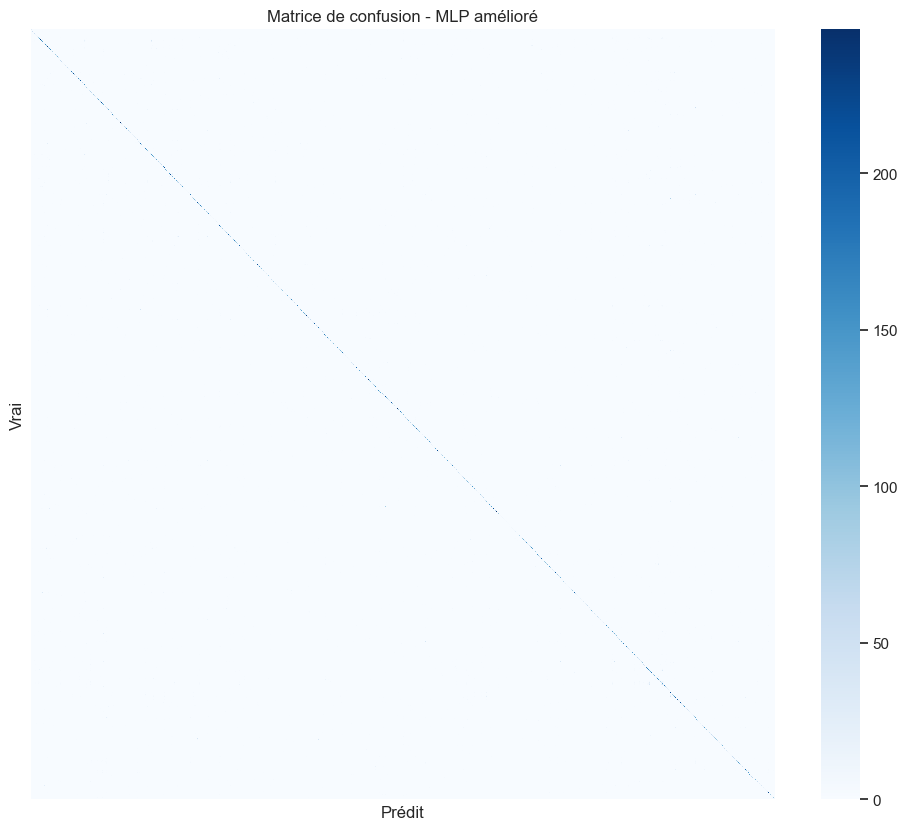

In [7]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues", xticklabels=False, yticklabels=False)
plt.title("Matrice de confusion - MLP amélioré")
plt.xlabel("Prédit")
plt.ylabel("Vrai")
plt.show()

📗 Cellule 6 – Sauvegarde du meilleur modèle

In [8]:
SAVE_DIR = "joblibs"
os.makedirs(SAVE_DIR, exist_ok=True)

# Sauvegarde sklearn model
joblib.dump(mlp_model, os.path.join(SAVE_DIR, "model_analysis.joblib"))
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.joblib"))
joblib.dump(pca, os.path.join(SAVE_DIR, "pca.joblib"))
joblib.dump(label_encoder, os.path.join(SAVE_DIR, "label_encoder.joblib"))
encoder.save(os.path.join(SAVE_DIR, "encoder.keras"))

# Juste avant le scaler
symptom_columns = list(X.columns)

# Sauvegarder les noms de colonnes utilisées à l'entraînement
with open(os.path.join(SAVE_DIR, "symptom_columns.json"), "w") as f:
    json.dump(symptom_columns, f)


📗 Cellule 7 – Prédiction avec liste de symptômes activés

In [9]:
# Chargement du modèle
mlp_loaded = joblib.load("joblibs/model_analysis.joblib")
scaler = joblib.load("joblibs/scaler.joblib")
pca = joblib.load("joblibs/pca.joblib")
encoder = load_model("joblibs/encoder.keras")
label_encoder = joblib.load("joblibs/label_encoder.joblib")

# Recharge les données pour obtenir les colonnes de X
df = fetch_data()
df.fillna(0, inplace=True)
df["diseases_original"] = df["diseases"]
y = df["diseases_original"]
X = df.drop(columns=["diseases", "diseases_original"])
X = X.apply(lambda col: pd.factorize(col)[0] if col.dtypes == 'object' else col)

# Liste des symptômes activés (doit matcher les colonnes de X)
active_symptoms = ['shortness_of_breath', 'palpitations', 'sharp_abdominal_pain']

manual_input = pd.DataFrame([{
    col: 1 if col in active_symptoms else 0
    for col in X.columns
}])

# Pipeline
input_scaled = scaler.transform(manual_input)
input_pca = pca.transform(input_scaled)
input_encoded = encoder.predict(input_pca)

predicted_class = mlp_loaded.predict(input_encoded)[0]
predicted_proba = mlp_loaded.predict_proba(input_encoded)[0]
predicted_label = label_encoder.inverse_transform([predicted_class])[0]

print(f"\n✅ Prédiction : {predicted_label}")
print("\n🔍 Top 5 des maladies les plus probables :")
top5_idx = predicted_proba.argsort()[-5:][::-1]
for i in top5_idx:
    label = label_encoder.inverse_transform([i])[0]
    proba = predicted_proba[i] * 100
    print(f" - {label} : {proba:.2f}%")


1/1 [==============================] - 0s 54ms/step

✅ Prédiction : pericarditis

🔍 Top 5 des maladies les plus probables :
 - pericarditis : 42.62%
 - abdominal_aortic_aneurysm : 39.30%
 - cardiac_arrest : 5.38%
 - aortic_valve_disease : 2.93%
 - endocarditis : 2.70%
